In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

In [ ]:
# Cargar el conjunto de datos Iris
iris = datasets.load_iris()

In [ ]:
# Filtrar solo las dos primeras especies (Iris Setosa y Iris Versicolor)
X = iris.data[iris.target != 2, :2]  # Usamos solo las dos primeras características
y = iris.target[iris.target != 2]     # Filtramos las etiquetas para incluir solo dos clases

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [ ]:
# Crear el modelo SVM
model = SVC(kernel='linear')  # Usamos un kernel lineal para la clasificación


In [ ]:
# Entrenar el modelo
model.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
# Realizar predicciones
predictions = model.predict(X_test)


In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay, RocCurveDisplay

In [ ]:
# Calcular accuracy
accuracy = accuracy_score(y_test, predictions)
print(f'Accuracy: {accuracy:.2f}')

Accuracy: 1.00


In [ ]:
# Reporte de clasificación con precisión, recall, f1-score
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        13

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



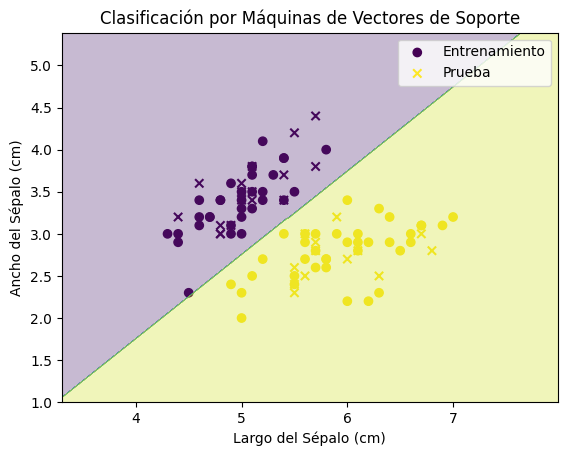

In [ ]:
# Visualizar los resultados
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, marker='o', label='Entrenamiento')
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, marker='x', label='Prueba')

# Crear una malla para visualizar la frontera de decisión
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)

plt.xlabel('Largo del Sépalo (cm)')
plt.ylabel('Ancho del Sépalo (cm)')
plt.title('Clasificación por Máquinas de Vectores de Soporte')
plt.legend(['Entrenamiento', 'Prueba'])
plt.show()


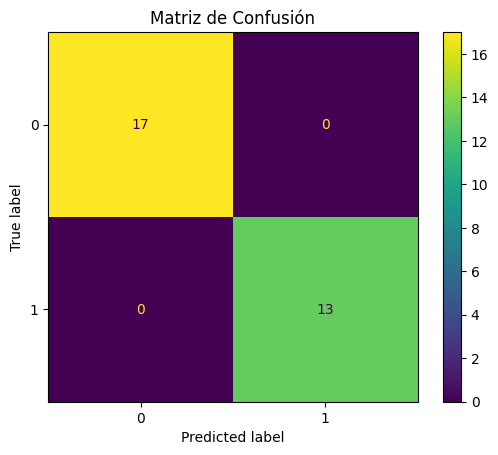

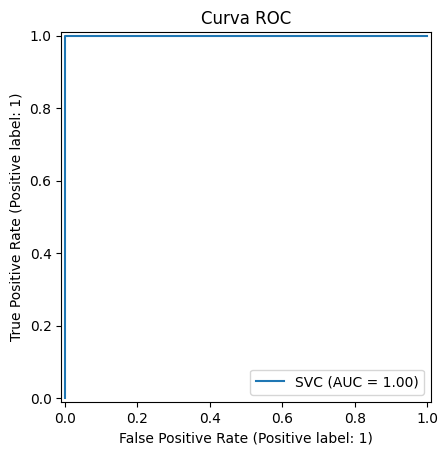

In [ ]:
# Matriz de confusión y gráfico
cm = confusion_matrix(y_test, predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Matriz de Confusión')
plt.show()

# Curva ROC y AUC (solo para clasificación binaria)
roc_disp = RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title('Curva ROC')
plt.show()